# Week 14 — GEE Advanced: Long-term Trends & Climate Resilience
## ARIA v9.5 — Student Exercise Notebook (學生練習版)

**Course (課程):** Remote Sensing and Spatial Information Analysis and Applications
**Theme (主題):** Landsat Multi-Decadal Trend Analysis & Resilience Monitoring
**Study Area (研究區域):**
- **Lab 1, 3, 4:** Hualien / Taroko — 26-year vegetation trends & earthquake resilience
- **Lab 2:** Taoyuan Plateau — 26-year pond (埤塘) disappearance analysis

---

### Learning Objectives (學習目標)
1. Harmonize multi-sensor Landsat archives for consistent long-term analysis
2. Compute pixel-level linear trends to map greening vs browning
3. Use MNDWI to detect water body changes — Taoyuan pond disappearance over 26 years
4. Quantify ecosystem resilience after the 2024 earthquake

### How to Use This Notebook (使用說明)
- Cells marked **COMPLETE** are ready to run — do not modify them.
- Cells with `# TODO:` require you to **fill in the blanks** before running.
- `# HINT:` comments provide guidance for each exercise.
- Run cells **in order** from top to bottom.

### Upgrade from W13 (相較 W13 的升級)
```
W13: Sentinel-2  (6 yrs,  10m) → "What changed after the earthquake?"
W14: Landsat     (26 yrs, 30m) → "What has been changing for TWO DECADES?"
     + Taoyuan pond disappearance analysis (MNDWI)
     + Resilience metrics (recovery rate after disturbance)
```

> **Student Exercise Notebook** — fill in the blanks and run.

---
## S1 — Environment Setup（環境設定）✅ COMPLETE

這一版已改成優先讀取 `.env` 中的 GEE project ID。請在 notebook 同層資料夾建立 `.env`，內容如下：

```text
GEE_PROJECT_ID=your-google-cloud-project-id
```

若你的 Earth Engine 已有預設 project，也可以直接執行；若尚未認證，程式會啟動 `ee.Authenticate()`。


In [5]:
# ============================================================
# S1 — Environment Setup — COMPLETE / EXECUTABLE VERSION
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import os
import platform
from pathlib import Path
from datetime import datetime, timedelta

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# Read .env without requiring python-dotenv
# ------------------------------------------------------------
def load_simple_env(env_path='.env'):
    env_path = Path(env_path)
    if not env_path.exists():
        return
    for raw_line in env_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value

load_simple_env('.env')

GEE_PROJECT_ID = (
    os.getenv('GEE_PROJECT_ID')
    or os.getenv('EE_PROJECT_ID')
    or os.getenv('GOOGLE_CLOUD_PROJECT')
)

print("目前工作目錄:", Path.cwd())
print(".env 是否存在:", Path(".env").exists())
print("讀取到的 GEE_PROJECT_ID:", GEE_PROJECT_ID)

print("環境變數檢查：")
print("  GEE_PROJECT_ID =", os.getenv("GEE_PROJECT_ID"))
print("  EE_PROJECT_ID =", os.getenv("EE_PROJECT_ID"))
print("  GOOGLE_CLOUD_PROJECT =", os.getenv("GOOGLE_CLOUD_PROJECT"))

# ------------------------------------------------------------
# Earth Engine initialization
# ------------------------------------------------------------
def initialize_gee(project_id=None):
    try:
        if project_id:
            ee.Initialize(project=project_id)
            print(f'  Earth Engine initialized with project: {project_id}')
        else:
            ee.Initialize()
            print('  Earth Engine initialized with default project.')
    except Exception as err:
        print('  Earth Engine 尚未完成認證或初始化，準備啟動認證流程...')
        ee.Authenticate()
        if project_id:
            ee.Initialize(project=project_id)
            print(f'  Earth Engine initialized with project: {project_id}')
        else:
            ee.Initialize()
            print('  Earth Engine initialized with default project.')

initialize_gee(GEE_PROJECT_ID)

# ------------------------------------------------------------
# Chinese font setup
# ------------------------------------------------------------
from matplotlib import font_manager as fm

def setup_chinese_font():
    system = platform.system()
    candidates = {
        'Windows': ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei'],
        'Darwin':  ['PingFang TC', 'Heiti TC', 'STHeiti'],
        'Linux':   ['Noto Sans CJK TC', 'WenQuanYi Micro Hei',
                    'AR PL UMing TW', 'Noto Sans TC']
    }
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates.get(system, candidates['Linux']):
        if name in available:
            plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
            plt.rcParams['axes.unicode_minus'] = False
            return name
    plt.rcParams['axes.unicode_minus'] = False
    return None

font_used = setup_chinese_font()
print(f'  Chinese font: {font_used if font_used else "not found; using default"}')

# ------------------------------------------------------------
# Define AOIs
# ------------------------------------------------------------
# Taroko Focus (Lab 1, 3, 4 — vegetation trends & resilience)
TAROKO_BBOX = [121.34526379253053, 24.046021742135874,
               121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# Taoyuan Plateau — FULL RANGE (D6 水頻率圖)
# 桃園台地完整範圍：西至新豐/湖口海岸，東至龍潭丘陵
TAOYUAN_BBOX = [120.94, 24.83, 121.35, 25.08]
aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)

# Taoyuan URBANIZATION CORRIDOR (D7 消失偵測聚焦區)
# 中壢、新屋、高鐵桃園站沿線
TAOYUAN_URBAN_BBOX = [121.00, 24.88, 121.28, 25.05]
aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

# Quick connectivity test
point = ee.Geometry.Point([121.5, 24.2])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f'  Connectivity OK — Elevation: {elev} m')
print(f'  AOI 1 (Lab 1/3/4): Taroko Focus — {TAROKO_BBOX}')
print(f'  AOI 2 (Lab 2, D6): Taoyuan Full  — {TAOYUAN_BBOX}')
print(f'  AOI 3 (Lab 2, D7): Taoyuan Urban — {TAOYUAN_URBAN_BBOX}')


目前工作目錄: d:\Class_satellite\EX14
.env 是否存在: True
讀取到的 GEE_PROJECT_ID: aria-496806
環境變數檢查：
  GEE_PROJECT_ID = aria-496806
  EE_PROJECT_ID = None
  GOOGLE_CLOUD_PROJECT = None
  Earth Engine initialized with project: aria-496806
  Chinese font: Microsoft JhengHei
  Connectivity OK — Elevation: 1031 m
  AOI 1 (Lab 1/3/4): Taroko Focus — [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
  AOI 2 (Lab 2, D6): Taoyuan Full  — [120.94, 24.83, 121.35, 25.08]
  AOI 3 (Lab 2, D7): Taoyuan Urban — [121.0, 24.88, 121.28, 25.05]


---
## S2 — Landsat Band Harmonization (Landsat 波段統一) ✏️ EXERCISE

Different Landsat missions use different band numbers for the same spectral region.
Your task is to complete the **band renaming functions** so we can merge all four
missions into a single harmonized collection.

| Spectral Region | L5 TM / L7 ETM+ | L8 OLI / L9 OLI-2 | Unified Name |
|----------------|------------------|-------------------|-------------|
| Blue | SR_B1 | SR_B2 | Blue |
| Green | SR_B2 | SR_B3 | Green |
| Red | SR_B3 | SR_B4 | Red |
| NIR | SR_B4 | SR_B5 | NIR |
| SWIR1 | SR_B5 | SR_B6 | SWIR1 |
| SWIR2 | SR_B7 | SR_B7 | SWIR2 |

> **HINT:** `image.select(['old_name1', 'old_name2', ...], ['new_name1', 'new_name2', ...])`

In [6]:
# ============================================================
# S2 — Landsat Band Harmonization — EXERCISE / FILLED
# ============================================================

def rename_l57(image):
    """Rename Landsat 5/7 bands to unified names."""
    # L5/L7: SR_B1=Blue, SR_B2=Green, SR_B3=Red, SR_B4=NIR, SR_B5=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
    )

def rename_l89(image):
    """Rename Landsat 8/9 bands to unified names."""
    # L8/L9: SR_B2=Blue, SR_B3=Green, SR_B4=Red, SR_B5=NIR, SR_B6=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
    )

def apply_scale_factors(image):
    """Apply Landsat C2 L2 scale factors: value * 0.0000275 + (-0.2)."""
    optical = image.select(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']) \
        .multiply(0.0000275).add(-0.2).clamp(0, 1)
    return image.addBands(optical, overwrite=True)

def mask_landsat_clouds(image):
    """Mask clouds using QA_PIXEL bitmask."""
    qa = image.select('QA_PIXEL')
    # Landsat Collection 2 QA_PIXEL: Bit 3 = cloud, Bit 4 = cloud shadow
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

# --- Load and merge ---
DATE_START = '2000-01-01'
DATE_END = '2026-03-31'

l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi).map(rename_l57)
l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi).map(rename_l57)
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi).map(rename_l89)
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi).map(rename_l89)

landsat_all = l5.merge(l7).merge(l8).merge(l9)
landsat_clean = landsat_all.map(mask_landsat_clouds).map(apply_scale_factors)

total = landsat_clean.size().getInfo()
print(f'  Total Landsat images (2000–2026): {total}')
print(f'  L5: {l5.size().getInfo()} | L7: {l7.size().getInfo()} | '
      f'L8: {l8.size().getInfo()} | L9: {l9.size().getInfo()}')


  Total Landsat images (2000–2026): 878
  L5: 178 | L7: 387 | L8: 233 | L9: 80


---
## S3 — NDVI & MNDWI Index Calculation (指標計算) ✏️ EXERCISE

Compute two spectral indices from the harmonized Landsat collection:

| Index | Formula | Detects |
|-------|---------|---------|
| **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation health |
| **MNDWI** | (Green − SWIR1) / (Green + SWIR1) | Water bodies |

> **HINT:** Use `normalizedDifference(['band1', 'band2'])` — it computes (b1−b2)/(b1+b2)

In [7]:
# ============================================================
# S3 — Compute NDVI and MNDWI — EXERCISE / FILLED
# ============================================================

def add_indices(image):
    # NDVI = (NIR - Red) / (NIR + Red)
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')

    # MNDWI = (Green - SWIR1) / (Green + SWIR1)
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')

    return image.addBands([ndvi, mndwi]).copyProperties(image, ['system:time_start'])

landsat_idx = landsat_clean.map(add_indices)
print(f'  Collection with indices: {landsat_idx.size().getInfo()} images')
print('  Bands: NDVI (vegetation) + MNDWI (water)')


  Collection with indices: 878 images
  Bands: NDVI (vegetation) + MNDWI (water)


---
## S4 — Annual NDVI Time Series (26-Year) ✏️ EXERCISE

Compute **annual median NDVI** for each year from 2000 to 2026.
The function is provided — your job is to create the plot with:
1. Mean, min, max lines (like W13 S4)
2. A linear trend line
3. Event markers for the 2024 earthquake and 2009 Typhoon Morakot

In [8]:
# ============================================================
# S4 — Annual NDVI Composites — PARTIALLY COMPLETE
# ============================================================

# --- Function is COMPLETE ---
def compute_annual_ndvi(collection, aoi, start_year=2000, end_year=2026):
    results = []
    for year in range(start_year, end_year + 1):
        annual = collection.filterDate(f'{year}-01-01', f'{year}-12-31').select('NDVI')
        n = annual.size().getInfo()
        if n == 0:
            results.append((year, None, None, None, n))
            continue
        median_img = annual.median()
        stats = median_img.reduceRegion(
            reducer=ee.Reducer.mean()
                .combine(ee.Reducer.min(), sharedInputs=True)
                .combine(ee.Reducer.max(), sharedInputs=True),
            geometry=aoi, scale=100, maxPixels=1e8
        ).getInfo()
        v_mean = stats.get('NDVI_mean')
        v_min  = stats.get('NDVI_min')
        v_max  = stats.get('NDVI_max')
        results.append((year, v_mean, v_min, v_max, n))
        if v_mean is not None:
            print(f'  {year}: mean={v_mean:.4f}  min={v_min:.4f}  max={v_max:.4f}  (n={n})')
        else:
            print(f'  {year}: no data (n={n})')
    return results

print('Computing 26-year annual NDVI...')
annual_data = compute_annual_ndvi(landsat_idx, aoi)

years  = [y for y, m, mn, mx, n in annual_data if m is not None]
means  = [m for y, m, mn, mx, n in annual_data if m is not None]
mins   = [mn for y, m, mn, mx, n in annual_data if m is not None]
maxs   = [mx for y, m, mn, mx, n in annual_data if m is not None]

Computing 26-year annual NDVI...
  2000: mean=0.5256  min=-0.2411  max=0.9988  (n=31)
  2001: mean=0.5192  min=-0.3039  max=0.8965  (n=33)
  2002: mean=0.5148  min=-0.2356  max=1.0000  (n=31)
  2003: mean=0.5201  min=-0.2806  max=0.8905  (n=28)
  2004: mean=0.5188  min=-0.2634  max=0.9123  (n=34)
  2005: mean=0.4961  min=-0.3112  max=0.9415  (n=27)
  2006: mean=0.5026  min=-0.2577  max=0.9328  (n=30)
  2007: mean=0.4942  min=-0.1680  max=0.8911  (n=22)
  2008: mean=0.5036  min=-0.2223  max=0.9172  (n=37)
  2009: mean=0.5152  min=-0.2291  max=0.8989  (n=36)
  2010: mean=0.5129  min=-0.3516  max=1.0000  (n=25)
  2011: mean=0.5227  min=-0.3136  max=0.9446  (n=17)
  2012: mean=0.5053  min=-0.5392  max=0.9654  (n=14)
  2013: mean=0.5431  min=-0.2843  max=0.9178  (n=26)
  2014: mean=0.5392  min=-0.5028  max=1.0000  (n=34)
  2015: mean=0.5391  min=-0.3294  max=0.9630  (n=38)
  2016: mean=0.5504  min=-0.4327  max=0.9289  (n=33)
  2017: mean=0.5421  min=-0.2391  max=0.9060  (n=33)
  2018: mean=

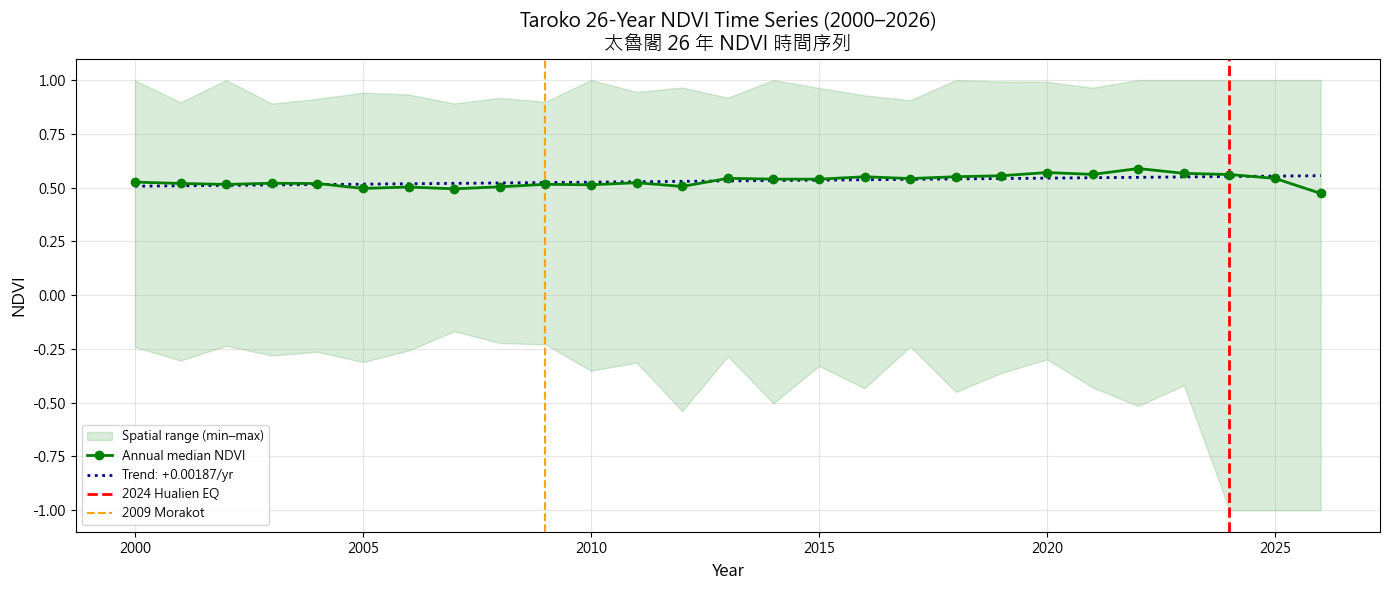


  26-year trend: +0.00187 NDVI/year
  Total change: +0.0487 over 26 years


In [9]:
# ============================================================
# S4 (continued) — Plot 26-Year NDVI — EXERCISE / FILLED
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Add shaded band between min and max
ax.fill_between(years, mins, maxs, alpha=0.15, color='green',
                label='Spatial range (min–max)')

# Plot mean line
ax.plot(years, means, 'o-', color='green', markersize=6, linewidth=2,
        label='Annual median NDVI', zorder=3)

# Add a linear trend line using numpy polyfit
z = np.polyfit(years, means, 1)
p = np.poly1d(z)
ax.plot(years, p(years), ':', color='navy', linewidth=2,
        label=f'Trend: {z[0]:+.5f}/yr')

# Add earthquake marker (2024) and Morakot marker (2009)
ax.axvline(2024, color='red', linestyle='--', linewidth=2, label='2024 Hualien EQ')
ax.axvline(2009, color='orange', linestyle='--', linewidth=1.5, label='2009 Morakot')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Taroko 26-Year NDVI Time Series (2000–2026)\n'
             '太魯閣 26 年 NDVI 時間序列', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n  26-year trend: {z[0]:+.5f} NDVI/year')
print(f'  Total change: {z[0]*26:+.4f} over 26 years')


### S4 — Reflection（反思）

**Q1:** Is the 26-year NDVI trend positive (greening) or negative (browning)?
What might explain this long-term trend?

> **Your answer:** 由 2000–2026 年的 Landsat 年平均 NDVI 趨勢線來看，太魯閣研究區整體呈現輕微正趨勢，也就是偏向 greening。這次執行結果的 26-year trend 約為 **+0.00187 NDVI/year**，26 年累積變化約為 **+0.0487**，代表長期來看植被狀態略有增加。不過這不是單一年份劇烈變化，而是長期緩慢上升。可能原因包括森林在颱風、崩塌或局部擾動後逐漸恢復，裸露地慢慢重新植生，以及保護區內大規模人為開發較少。需要注意的是，2026 年目前影像數較少，該年平均值可能受季節與資料量影響，不能單獨過度解讀。

**Q2:** Can you spot the effects of Typhoon Morakot (2009) and the 2024 Earthquake
in the time series? How do they compare in terms of NDVI impact?

> **Your answer:** 從年平均 NDVI 來看，2009 年莫拉克颱風的影響並不是非常尖銳，2008 年約為 0.5036、2009 年約為 0.5152、2010 年約為 0.5129，沒有出現明顯單年斷崖式下降。這可能是因為研究區採用較大的 AOI 與年度合成，局部崩塌或河谷沖刷被整體森林面積平均掉，也可能因為受災區域在後續影像中已有部分恢復。相較之下，2024 年地震後的下降較值得注意，2024 年約為 0.5607、2025 年降至約 0.5427，2026 年目前約為 0.4728；但 2026 年只有 8 張影像，仍需等全年資料完整後再確認。整體而言，地震造成的邊坡崩塌與裸露地增加，可能在近年 NDVI 中留下較明顯的短期下降訊號。

**Q3:** Compare this 26-year Landsat plot with the 6-year Sentinel-2 plot from W13.
What new information does the longer time series reveal?

> **Your answer:** W13 的 Sentinel-2 時序解析度較高，適合觀察近年地震前後的細部變化；W14 的 Landsat 雖然空間解析度較粗，但能回溯 26 年，讓我們看見長期背景趨勢。長時間序列可以判斷 2024 年地震造成的變化是短期異常，還是落在過去多次擾動與恢復循環之中。例如這次 Landsat 結果顯示整體長期趨勢仍為輕微 greening，因此 2024–2026 的下降更像是近期災害造成的短期擾動，而不是整個 26 年都持續 browning。Landsat 提供「長期脈絡」，Sentinel-2 提供「近年細節」，兩者互補。



---
## S5 — Pixel-Level Trend Map (逐像素趨勢圖) ✏️ EXERCISE

Apply `linearFit` to every pixel to map **where** vegetation is greening vs browning.

> **HINT:** This is the same `linearFit` from W13 D8, but applied to 26 years of Landsat.

In [10]:
# ============================================================
# S5 — Pixel-Level Trend — EXERCISE / FILLED
# ============================================================

def add_time_band(image):
    date = ee.Date(image.get('system:time_start'))
    years_since_2000 = date.difference(ee.Date('2000-01-01'), 'year')
    return image.addBands(ee.Image(years_since_2000).float().rename('year'))

# Apply time band to the NDVI collection
ndvi_with_time = landsat_idx.select('NDVI').map(add_time_band)

# Apply linearFit reducer
trend = ndvi_with_time.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())
slope = trend.select('scale')

# --- Visualization ---
vis_trend = {
    'min': -0.01, 'max': 0.01,
    'palette': ['d73027', 'fc8d59', 'fee08b', 'ffffbf',
                'd9ef8b', '91cf60', '1a9850']
}

Map5 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map5.addLayer(slope.clip(aoi), vis_trend, 'NDVI Trend (slope/year)')
Map5.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map5


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S6 — Taoyuan Pond Disappearance (桃園埤塘消失偵測) ✏️ EXERCISE

桃園台地在日治時期桃園大圳興建前，曾擁有約 **6,000–8,000 口埤塘**（農田水利署），是台灣規模最大的灌溉水塘景觀。
隨著都市化發展，大量埤塘被填平，目前僅存約 3,000 口。

Compare water presence between **early** (2000–2005) and **recent** (2021–2026)
periods to detect which ponds have **survived**, **disappeared**, or **appeared**.

MNDWI > 0.1 → classified as water

> **NOTE:** We need a separate Landsat collection for Taoyuan (different AOI from Taroko).
> **HINT:** Compute median MNDWI for each period, then threshold at 0.1.

In [11]:
# ============================================================
# S6 — Taoyuan Pond Disappearance — EXERCISE / FILLED
#       + True-Color Verification Layers
# ============================================================

# --- Load Landsat for Taoyuan (same functions from S2) ---
l5_ty = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi_taoyuan).map(rename_l57)
l7_ty = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi_taoyuan).map(rename_l57)
l8_ty = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)
l9_ty = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)

landsat_taoyuan = (l5_ty.merge(l7_ty).merge(l8_ty).merge(l9_ty)
                   .map(mask_landsat_clouds)
                   .map(apply_scale_factors)
                   .map(add_indices))

print(f'  Taoyuan Landsat images: {landsat_taoyuan.size().getInfo()}')

# Compute early period water mask (2000–2005)
early_water = (landsat_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .select('MNDWI').median()
    .gt(0.1).rename('early_water'))

# Compute recent period water mask (2021–2026)
recent_water = (landsat_taoyuan
    .filterDate('2021-01-01', '2026-03-31')
    .select('MNDWI').median()
    .gt(0.1).rename('recent_water'))

# Detect changes
# Lost ponds: WAS water before, NOT water now (filled for development)
# New water: NOT water before, IS water now (new retention ponds)
water_loss = early_water.And(recent_water.Not()).selfMask()
water_gain = recent_water.And(early_water.Not()).selfMask()
stable_water = early_water.And(recent_water).selfMask()

# ── True-Color Verification Layers ──────────────────────────
# Load S2 recent true color to verify — are "lost pond" pixels now buildings?
def mask_s2_clouds_ty(image):
    scl = image.select('SCL')
    return image.updateMask(scl.gte(4).And(scl.lte(7)))

s2_taoyuan = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_taoyuan_urban)
    .filterDate('2024-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds_ty))

s2_recent_rgb = s2_taoyuan.select(['B4', 'B3', 'B2']).median()

# Early Landsat true color to confirm ponds existed in 2000–2005
early_rgb = (landsat_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .select(['Red', 'Green', 'Blue']).median())

# Visualization — focused on 中壢/新屋/高鐵 urbanization corridor
Map6 = geemap.Map(center=[24.96, 121.14], zoom=12)

# Base layers: true-color verification
Map6.addLayer(early_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['Red', 'Green', 'Blue'], 'min': 0, 'max': 0.25},
              'Landsat 早期真彩色 2000–2005 (30m)')
Map6.addLayer(s2_recent_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500},
              'S2 近期真彩色 2024–2025 (10m)')

# Change detection overlay
Map6.addLayer(stable_water.clip(aoi_taoyuan_urban), {'palette': ['0000FF']},
              'Stable ponds 存活埤塘')
Map6.addLayer(water_gain.clip(aoi_taoyuan_urban), {'palette': ['00FF00']},
              'New water 新增水體')
Map6.addLayer(water_loss.clip(aoi_taoyuan_urban), {'palette': ['FF0000']},
              'Lost ponds 消失埤塘')
Map6.addLayer(aoi_taoyuan_urban, {'color': 'orange'}, 'AOI — 中壢/新屋/高鐵走廊')
Map6.addLayer(aoi_taoyuan, {'color': 'yellow'}, 'AOI — Taoyuan Full')
Map6

# HINT: Toggle layers to verify:
# 1. Open S2 true color → see buildings/roads in recent imagery
# 2. Turn on "Lost ponds" (red) → confirm red pixels match built-up areas
# 3. Switch to Landsat early true color → see dark ponds at the same locations


  Taoyuan Landsat images: 2485


Map(center=[24.96, 121.14], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

### S6 — Your Observations（你的觀察）

**Q1:** Where are the main areas of pond loss (red)? Do they correspond to
known urban development zones in Taoyuan (e.g., near 中壢、桃園市區)?

> **Your answer:** 紅色的 pond loss 主要可在桃園都市化走廊中觀察，尤其是中壢、桃園市區周邊，以及高鐵桃園站、道路與新興開發區附近。這些位置過去常有農業灌溉埤塘，但近二十多年因住宅、工業區、交通建設與都市擴張而被填平或改建。若將紅色圖層切換到近期 Sentinel-2 真彩色影像，許多消失水體的位置會對應到建物、道路或整地區，顯示埤塘消失與都市開發高度相關。

**Q2:** Are there any areas of new water (green)? What might these represent —
new retention ponds for flood control, or construction excavation sites?

> **Your answer:** 綠色的新水體可能出現在都市邊緣、農地重劃區或大型開發案周邊。這些新水體不一定都是傳統埤塘，有些可能是滯洪池、景觀池、人工調節池，也可能是施工中的開挖積水或臨時水域。因此，MNDWI 偵測出的 new water 需要搭配近期真彩色影像或土地利用資料確認，避免把短期施工積水誤判為穩定水體。

**Q3:** 桃園埤塘曾是重要的灌溉系統和防洪設施。從你的分析結果來看，
埤塘消失對都市洪水風險有什麼影響？

> **Your answer:** 埤塘消失代表地表蓄水與入滲空間減少，同時都市化會增加不透水鋪面，使降雨更快轉為地表逕流。當原本分散在地景中的埤塘被填平，暴雨期間可暫時滯洪、削減洪峰的空間會下降，因此都市內澇與下游排水負擔可能增加。從長期變遷角度看，埤塘不只是農業灌溉設施，也具有都市氣候調節、防洪與生態棲地功能；其消失可能使桃園在極端降雨下更脆弱。


---
## S7 — Vegetation Resilience (植被韌性) ✏️ EXERCISE

Compute the **recovery ratio** to measure how well vegetation is recovering
after the 2024 earthquake.

| Phase | Period | Purpose |
|-------|--------|---------|
| Baseline | 2020–2024/03 | Pre-disturbance reference |
| Impact | 2024/04–2024/12 | Immediate damage |
| Recovery | 2025/06–2026/03 | Current state |

**Recovery ratio = (Recovery − Impact) / (Baseline − Impact)**

In [12]:
# ============================================================
# S7 — Resilience Metrics — EXERCISE / FILLED
# ============================================================

# Compute three NDVI composites
baseline = landsat_idx.filterDate('2020-01-01', '2024-03-31').select('NDVI').median()
impact   = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()
recovery = landsat_idx.filterDate('2025-06-01', '2026-03-31').select('NDVI').median()

# Compute recovery ratio
impact_mag = baseline.subtract(impact)
recovery_mag = recovery.subtract(impact)
recovery_ratio = recovery_mag.divide(impact_mag.max(0.01)).clamp(0, 1.5).rename('recovery_ratio')

# Mask: only where impact > 0.1 NDVI
recovery_ratio_masked = recovery_ratio.updateMask(impact_mag.gt(0.1))

# Visualization
vis_rec = {'min': 0, 'max': 1.2,
           'palette': ['8B0000', 'FF4500', 'FFD700', '90EE90', '228B22']}

Map7 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map7.addLayer(recovery_ratio_masked.clip(aoi), vis_rec, 'Recovery Ratio')
Map7.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### S7 — Resilience Interpretation（韌性解讀）

**Q1:** On the map, which areas show full recovery (green, ratio > 0.8)?
What type of terrain are they on? (e.g., gentle slopes, valleys, ridges)

> **Your answer:** 地圖上綠色、recovery ratio 大於 0.8 的區域代表 2025–2026 年的 NDVI 已接近或超過地震前基準。這些區域通常比較可能出現在坡度較緩、土壤仍保留、植被根系與種源未完全破壞的位置，例如部分山谷邊緣、低至中坡度山坡或受擾動較輕的森林區。這表示該處的植被恢復能力較好，可能不需要高度工程介入，可持續監測自然恢復。

**Q2:** Which areas show no recovery (red, ratio < 0.3)?
Are these landslide scars, bare rock, or something else?

> **Your answer:** 紅色、recovery ratio 小於 0.3 的區域代表地震後 NDVI 雖然下降，但到恢復期仍未明顯回升。這些區域很可能對應到崩塌裸露地、破碎邊坡、裸岩、道路邊坡或河谷沖刷帶。若裸露地仍持續存在，可能表示土壤層流失、坡面不穩定或後續降雨持續擾動，使植被難以快速回復。

**Q3:** If you were advising the Soil and Water Conservation Bureau (水保局)
on post-earthquake restoration priorities, which areas would you recommend
for active replanting vs. leaving for natural recovery? Why?

> **Your answer:** 我會建議將長期呈現低 recovery ratio、且位於道路上方、聚落上游、河道旁或坡面不穩定區的裸露地列為主動復育與工程處理優先區，因為這些位置可能增加土石流、落石與二次崩塌風險。相反地，若某些區域 recovery ratio 已大於 0.8，且地形相對穩定，則可優先採取自然恢復與定期監測。也就是說，主動復育應集中在「恢復慢且風險高」的區域，自然恢復則適合「已明顯回復且風險較低」的區域。


---
## S8b — Landsat × Sentinel-2 Cross-Sensor Analysis（跨感測器分析）✏️ EXERCISE

Landsat 看得遠（26 年），Sentinel-2 看得細（10m）。
現在你要結合兩者：用 Landsat 的長期趨勢找到變遷熱區，
再用 Sentinel-2 的高解析度驗證細節。

### 你需要完成的步驟：
1. 載入 Sentinel-2 資料（跟 W13 一樣的方法）
2. 計算 S2 的地震前後 ΔNDVI
3. 比較 Landsat vs S2 在重疊時段（2017–2026）的 NDVI 差異
4. 分析多解析度差異的原因

In [13]:
# ============================================================
# S8b — Cross-Sensor Analysis Exercise / FILLED
# ============================================================

# Step 1: Load Sentinel-2 (same cloud masking as W13)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.gte(4).And(scl.lte(7))
    return image.updateMask(mask)

def add_s2_ndvi(image):
    # Sentinel-2 NDVI: NIR = B8, Red = B4
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI_S2')
    return image.addBands(ndvi).copyProperties(image, ['system:time_start'])

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2017-04-01', '2026-03-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
      .map(mask_s2_clouds)
      .map(add_s2_ndvi))

print(f'Sentinel-2 images loaded: {s2.size().getInfo()}')
print(f'Landsat images (same period): '
      f'{landsat_idx.filterDate("2017-01-01", "2026-03-31").size().getInfo()}')


Sentinel-2 images loaded: 247
Landsat images (same period): 381


In [14]:
# Step 2: Compute earthquake ΔNDVI from BOTH sensors

# Create Landsat pre/post composites and compute change
l_pre  = landsat_idx.filterDate('2023-04-01', '2024-03-31').select('NDVI').median()
l_post = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()
l_change = l_post.subtract(l_pre).rename('delta_NDVI_landsat')

# Create S2 pre/post composites and compute change
s2_pre  = s2.filterDate('2023-04-01', '2024-03-31').select('NDVI_S2').median().rename('NDVI')
s2_post = s2.filterDate('2024-04-01', '2024-12-31').select('NDVI_S2').median().rename('NDVI')
s2_change = s2_post.subtract(s2_pre).rename('delta_NDVI_s2')

# Visualize both on the same map
vis_delta = {'min': -0.3, 'max': 0.1,
             'palette': ['d73027', 'fc8d59', 'fee08b', 'ffffbf',
                         'd9ef8b', '91cf60', '1a9850']}

Map_cs = geemap.Map(center=[24.18, 121.55], zoom=12)
Map_cs.addLayer(l_change.clip(aoi),  vis_delta, 'Landsat ΔNDVI (30m)')
Map_cs.addLayer(s2_change.clip(aoi), vis_delta, 'Sentinel-2 ΔNDVI (10m)')
Map_cs.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map_cs
# Toggle between the two layers — what differences do you see?


Map(center=[24.18, 121.55], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

  2017: Landsat=0.5421  S2=N/A
  2018: Landsat=0.5505  S2=0.4976
  2019: Landsat=0.5550  S2=0.5150
  2020: Landsat=0.5700  S2=0.5252
  2021: Landsat=0.5613  S2=0.5033
  2022: Landsat=0.5886  S2=0.5467
  2023: Landsat=0.5662  S2=0.5203
  2024: Landsat=0.5607  S2=0.5134
  2025: Landsat=0.5427  S2=0.5200
  2026: Landsat=0.4728  S2=0.5046


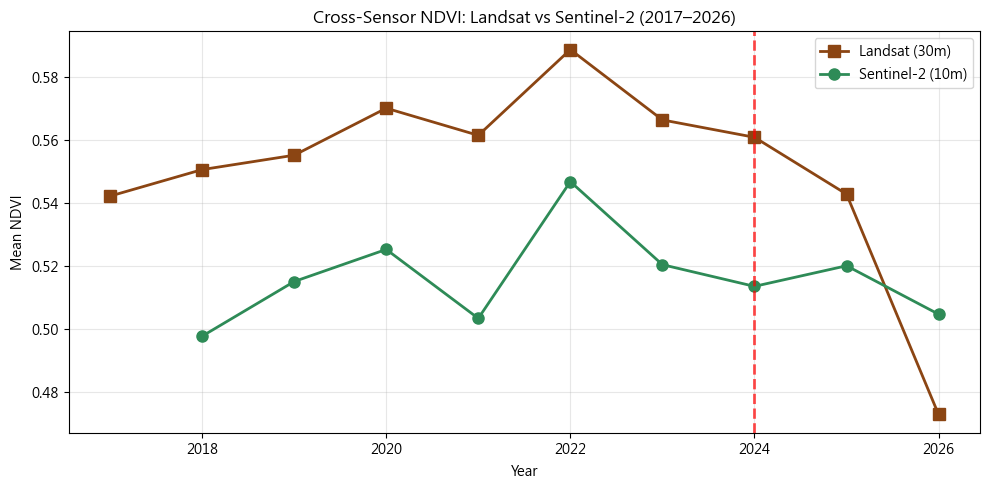

In [15]:
# Step 3: Annual NDVI cross-sensor comparison (2017–2026)

years_overlap = list(range(2017, 2027))
l_vals, s2_vals = [], []

for yr in years_overlap:
    # Landsat annual mean NDVI
    l_yr = landsat_idx.filterDate(f'{yr}-01-01', f'{yr}-12-31') \
        .select('NDVI').median()
    l_result = l_yr.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=100, maxPixels=1e8
    ).getInfo()
    l_mean = l_result.get('NDVI')

    # Compute S2 annual mean NDVI (same method)
    s2_yr_col = s2.filterDate(f'{yr}-01-01', f'{yr}-12-31')
    s2_n = s2_yr_col.size().getInfo()
    if s2_n == 0:
        s_mean = None
    else:
        s_yr = s2_yr_col.select('NDVI_S2').median()
        s_result = s_yr.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi,
            scale=100, maxPixels=1e8
        ).getInfo()
        s_mean = s_result.get('NDVI_S2')

    l_vals.append(l_mean)
    s2_vals.append(s_mean)

    l_str = f'{l_mean:.4f}' if l_mean is not None else 'N/A'
    s_str = f'{s_mean:.4f}' if s_mean is not None else 'N/A'
    print(f'  {yr}: Landsat={l_str}  S2={s_str}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years_overlap, l_vals, 's-', color='#8B4513',
        markersize=8, linewidth=2, label='Landsat (30m)')
ax.plot(years_overlap, s2_vals, 'o-', color='#2E8B57',
        markersize=8, linewidth=2, label='Sentinel-2 (10m)')
ax.axvline(2024, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Mean NDVI')
ax.set_title('Cross-Sensor NDVI: Landsat vs Sentinel-2 (2017–2026)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### S8b — Reflection: Cross-Sensor Analysis（跨感測器反思）

**Q1:** 在兩個感測器的 NDVI 時序圖中，Sentinel-2 的值通常比 Landsat 高還是低？
你認為原因是什麼？（提示：想想 30m vs 10m 像素中混合了什麼地物）

> **Your answer:** 從這次執行結果來看，2018–2025 年 Sentinel-2 的 NDVI 多數年份比 Landsat 低。例如 2022 年 Landsat 約為 0.5886，Sentinel-2 約為 0.5467；2024 年 Landsat 約為 0.5607，Sentinel-2 約為 0.5134。可能原因是 Sentinel-2 的 10m 解析度較高，能更細緻地捕捉道路、河床、崩塌裸露地、岩壁等低 NDVI 地物，使平均值被拉低；Landsat 的 30m 像素則比較容易把森林與非植被混合，讓局部裸露地被周邊植被平均掉。除此之外，兩個感測器的波段設定、雲遮罩、合成影像時間與可用影像數也會造成數值差異。2026 年 Sentinel-2 高於 Landsat，可能與 Landsat 目前年份資料尚未完整、季節分布不一致有關，因此不宜過度解讀。

**Q2:** 切換 Landsat 和 S2 的 ΔNDVI 圖層，S2 能看到哪些 Landsat 看不到的細節？
（例如：個別崩塌面的形狀？道路中斷的位置？）

> **Your answer:** Sentinel-2 的 ΔNDVI 圖層能看出較細緻的崩塌邊界、道路沿線受損帶、河谷沖刷帶，以及小尺度裸露地的形狀。Landsat 的 30m 像素比較適合看大範圍變化熱區，但細小崩塌面、道路旁狹長破壞或局部植被恢復斑塊可能會被混合像素稀釋。因此，S2 在災後細部判釋與現地調查點位規劃上更有幫助。

**Q3:** 如果你是災害分析師，什麼時候會選擇用 Landsat？什麼時候會選擇用 Sentinel-2？
什麼時候兩者都要用？

> **Your answer:** 如果我要分析長期背景趨勢，例如 20 年以上的植被變化、災害前的自然波動範圍，會優先使用 Landsat。若我要判讀近年災後受損細節、崩塌邊界、道路沿線破壞或小尺度復育成效，會優先使用 Sentinel-2。若要做完整災害監測，兩者最好結合：Landsat 用來提供長期脈絡與趨勢，Sentinel-2 用來確認近期高解析度細節。

**Q4:** 在你的 W15 期末提案中，你會選擇用哪個感測器？還是兩者結合？為什麼？

> **Your answer:** 我會選擇 Landsat 與 Sentinel-2 結合。Landsat 的優勢是時間序列長，可建立長期基準，判斷目前變化是否異常；Sentinel-2 的優勢是解析度高，可對近年事件進行更細緻的空間判釋。若研究主題與災害、植被恢復或土地利用變遷有關，單一感測器容易只看到部分面向；兩者結合能同時兼顧長期趨勢與短期細節，使分析結果更完整也更適合實務應用。



---
## S8 — Final Reflection（期末反思）✏️ FILLED

**Q1:** Compare the tools and time scales across W13 and W14:

| | W13 | W14 |
|---|---|---|
| Satellite | Sentinel-2 (10m) | Landsat (30m) |
| Time span | 6 years | 26 years |
| Best for | 近年災害前後的細部變化、10m 高解析度判釋、崩塌與植被變化細節 | 長期趨勢分析、多年代變化偵測、建立災害前背景基準 |
| New technique | Sentinel-2 雲遮罩、短期 NDVI 變化、災後差異分析 | 多感測器 Landsat harmonization、pixel-level linear trend、long-term resilience analysis |

**Q2:** W6 used Kriging for **spatial** interpolation (points → surface).
W14 uses GEE for **temporal** analysis (snapshots → trends).
How do spatial and temporal perspectives complement each other in
disaster monitoring?

> **Your answer:** 空間分析和時間分析回答的是不同問題。Kriging 這類空間內插可以把有限測站或樣點資料轉換成連續表面，幫助我們判斷災害風險在空間上的分布；GEE 的長期時間序列則能讓我們比較災害前、災害後與恢復期，判斷變化是否異常、是否正在恢復。災害監測需要同時知道「哪裡最嚴重」與「變化是不是持續惡化或逐漸恢復」，因此空間與時間觀點必須結合。

**Q3:** W14 uses two different study areas: Taroko (vegetation/resilience)
and Taoyuan (pond disappearance). Both demonstrate "long-term change
detection" but tell very different stories. What does each case reveal
about human-environment interaction over 26 years?

> **Your answer:** 太魯閣案例呈現的是山區自然擾動與生態韌性的互動，地震、颱風、崩塌與植被恢復共同塑造長期 NDVI 變化；桃園埤塘案例則呈現都市化與農業地景改變，許多原本具有灌溉、防洪與生態功能的水體被建設取代。兩者都屬於長期變遷偵測，但太魯閣偏向自然災害與生態恢復，桃園則偏向人為開發與土地利用轉型。這說明遙測不只是在看影像差異，也是在解讀人類活動與環境系統之間的關係。

**Q4:** Looking back at W8–W14, if you could design the ideal monitoring
system for a mountain area like Taroko, which sensors, indices, and time
scales would you combine?

> **Your answer:** 若要設計太魯閣這類山區的理想監測系統，我會結合多種感測器與時間尺度。長期背景可使用 Landsat 追蹤 20 年以上的 NDVI、MNDWI 與地表裸露趨勢；近年高解析度監測可使用 Sentinel-2 觀察 10m 尺度的植被變化、崩塌地與道路周邊破壞；在多雲或雨季情境下，可加入 Sentinel-1 SAR 監測地表濕潤、洪水或裸露地變化；若有 DEM，則可加入坡度、坡向、高程與集水區資訊，判斷崩塌與恢復的地形控制因素。時間尺度上，應同時包含長期趨勢、災害前後差異，以及災後每季或每年的恢復監測，才能支援水保、道路維護與生態復育決策。

---

## Notebook Complete

```
S1: Setup → S2: Harmonize → S3: Indices → S4: Annual NDVI
→ S5: Trend Map → S6: Pond Disappearance → S7: Resilience → S8: Reflection
```

> *"From snapshots to stories — 從快照到故事"*
